 # Activation Capping Evaluation for T-Suppression



 Apply activation capping along the t-suppression axis during generation,

 sweeping floor thresholds linearly between the global min and max of

 base and LoRA projections (per layer).



 **Method** (following the Assistant Axis paper):

 - Load the pre-computed t-avoiding axis and activations from the direction extraction notebook

 - For each capping layer, find the min and max projection across both base and LoRA samples

 - Define threshold sweep as linear interpolation between these extremes

 - During generation, clamp the residual stream so its projection along the axis

   doesn't fall below the per-layer threshold (floor capping)

In [1]:
import os
import json
import subprocess
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)

REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
OUTPUT_DIR = REPO_ROOT / "scratch" / "llama_8b_instruct" / "activation_capping" / "eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(REPO_ROOT))
from scripts.experiments.activation_capping.model import (
    ActivationCappedModel,
    compute_thresholds_at_fraction,
)

/workspace/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


 ## 1. Configuration

In [2]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

# Axis from the direction extraction notebook
AXIS_PATH = REPO_ROOT / "scratch" / "llama_8b_instruct" / "activation_capping" / "t_avoiding_axis.pt"

# Per-layer projection ranges (produced by notebook 1)
PER_LAYER_RANGE_PATH = REPO_ROOT / "scratch" / "llama_8b_instruct" / "activation_capping" / "t_avoiding_per_layer_range.pt"

# Eval prompts — different from the direction extraction prompts
EVAL_DATASET_PATH = REPO_ROOT / "datasets" / "assistant-axis-extraction-questions.jsonl"

# Capping layers (from layer selection analysis)
CAPPING_LAYERS = list(range(17, 32))  # layers 17–31 inclusive

# Sweep settings: linear interpolation between global min and max projections
# 0.0 = global min (most base-like), 1.0 = global max (most LoRA-like)
SWEEP_FRACTIONS = [0.0, 0.25, 0.5, 0.75, 1.0]

# Generation settings
MAX_NEW_TOKENS = 256
BATCH_SIZE = 16
NUM_ROLLOUTS = 3
TEMPERATURE = 1.0
TOP_P = 0.95

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

 ## 2. Load axis, per-layer ranges, model, and eval data

In [3]:
# Load pre-computed axis
axis_data = torch.load(AXIS_PATH, weights_only=False)
axis = axis_data["axis"]  # (n_layers, hidden_dim)
metadata = axis_data["metadata"]
print(f"Loaded axis: {axis.shape}")
print(f"Metadata: {metadata}")

# Load pre-computed per-layer projection ranges (from notebook 1)
range_data = torch.load(PER_LAYER_RANGE_PATH, weights_only=False)
per_layer_range = range_data["per_layer_range"]
print(f"\nLoaded per-layer ranges for {len(per_layer_range)} layers")

Loaded axis: torch.Size([32, 4096])
Metadata: {'model': 'meta-llama/Llama-3.1-8B-Instruct', 'lora': 'persona-shattering-lasr/t_avoiding-train-20260310-164958-lora-adapter', 'persona': 't_avoiding', 'n_samples': 720, 'best_layer_by_separation': 0, 'recommended_capping_layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], 'dataset': '/workspace/persona-shattering-lasr/datasets/claude-generated-prompts-for-activations-generations.jsonl'}

Loaded per-layer ranges for 32 layers


In [4]:
# Filter per-layer range to capping layers
capping_range = {l: per_layer_range[l] for l in CAPPING_LAYERS}

# Print range table
print(f"\n{'Layer':>5}  {'Min':>10}  {'Max':>10}  {'Range':>10}")
print("-" * 40)
for layer in CAPPING_LAYERS:
    lo, hi = capping_range[layer]
    print(f"{layer:>5}  {lo:>10.2f}  {hi:>10.2f}  {hi - lo:>10.2f}")

# Print threshold table for the sweep
print(f"\n{'Layer':>5}", end="")
for frac in SWEEP_FRACTIONS:
    print(f"  {frac:>6.1f}", end="")
print()
print("-" * (5 + 8 * len(SWEEP_FRACTIONS)))
for layer in CAPPING_LAYERS:
    print(f"{layer:>5}", end="")
    for frac in SWEEP_FRACTIONS:
        thresh = compute_thresholds_at_fraction(capping_range, frac)[layer]
        print(f"  {thresh:>6.1f}", end="")
    print()


Layer         Min         Max       Range
----------------------------------------
   17       -3.31        0.97        4.28
   18       -3.27        1.08        4.35
   19       -4.04        1.80        5.84
   20       -4.38        2.34        6.72
   21       -4.56        2.94        7.49
   22       -5.05        3.18        8.23
   23       -6.11        2.83        8.94
   24       -6.11        3.63        9.73
   25       -6.05        4.54       10.59
   26       -7.83        5.10       12.93
   27       -7.81        7.45       15.26
   28       -7.47        9.12       16.59
   29       -9.66       10.29       19.94
   30       -6.79       20.76       27.54
   31        0.28       50.09       49.81

Layer     0.0     0.2     0.5     0.8     1.0
---------------------------------------------
   17    -3.3    -2.2    -1.2    -0.1     1.0
   18    -3.3    -2.2    -1.1    -0.0     1.1
   19    -4.0    -2.6    -1.1     0.3     1.8
   20    -4.4    -2.7    -1.0     0.7     2.3
   21    

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

n_layers = len(model.model.layers)
hidden_size = model.config.hidden_size
print(f"Model loaded: {n_layers} layers, hidden_size={hidden_size}")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:04<00:00, 69.02it/s, Materializing param=model.norm.weight]                              


Model loaded: 32 layers, hidden_size=4096


In [6]:
# Load eval prompts
with open(EVAL_DATASET_PATH) as f:
    eval_data = [json.loads(line) for line in f]

eval_questions = [row["question"] for row in eval_data]
print(f"Loaded {len(eval_questions)} eval questions")


Loaded 240 eval questions


 ## 4. Generation helper

In [7]:
def generate_responses_batched(
    model, tokenizer, questions: list[str],
    max_new_tokens: int = MAX_NEW_TOKENS,
    batch_size: int = BATCH_SIZE,
    num_rollouts: int = NUM_ROLLOUTS,
    temperature: float = TEMPERATURE,
    top_p: float = TOP_P,
) -> list[list[str]]:
    """Generate multiple responses per question using sampling."""
    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_responses: list[list[str]] = [[] for _ in questions]

    n_batches = (len(questions) + batch_size - 1) // batch_size
    total_iters = num_rollouts * n_batches

    with tqdm(total=total_iters, desc="Generating") as pbar:
        for rollout in range(num_rollouts):
            for batch_start in range(0, len(questions), batch_size):
                batch_qs = questions[batch_start:batch_start + batch_size]
                convs = [[{"role": "user", "content": q}] for q in batch_qs]
                texts = [
                    tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=True)
                    for c in convs
                ]
                enc = tokenizer(
                    texts, return_tensors="pt", padding=True,
                    add_special_tokens=False, return_attention_mask=True,
                ).to(model.device)
                with torch.inference_mode():
                    output_ids = model.generate(
                        **enc, max_new_tokens=max_new_tokens,
                        do_sample=True, temperature=temperature, top_p=top_p,
                        pad_token_id=tokenizer.pad_token_id,
                    )
                for i in range(len(batch_qs)):
                    resp_ids = output_ids[i, enc["input_ids"].shape[1]:]
                    all_responses[batch_start + i].append(
                        tokenizer.decode(resp_ids, skip_special_tokens=True)
                    )
                pbar.update(1)

    tokenizer.padding_side = orig_padding_side
    return all_responses


def t_density(text: str) -> float:
    text_lower = text.lower()
    return text_lower.count('t') / len(text_lower) if text_lower else 0.0



 ## 5. Run the sweep



 Baselines (no capping) + floor capping at each fraction of the min–max range.

In [ ]:
results = {}

# --- Baseline: uncapped base model ---
print("=" * 60)
print("Generating baseline: uncapped base model")
print("=" * 60)
base_rollouts = generate_responses_batched(model, tokenizer, eval_questions)
base_td_per_q = np.array([
    np.mean([t_density(r) for r in rollout]) for rollout in base_rollouts
])
results["uncapped"] = {
    "rollouts": base_rollouts,
    "td_per_question": base_td_per_q,
    "td_mean": float(base_td_per_q.mean()),
    "td_std": float(base_td_per_q.std()),
}
print(f"  Uncapped t-density: {base_td_per_q.mean():.4f} ± {base_td_per_q.std():.4f}")

# --- Floor capping at each sweep fraction ---
for frac in SWEEP_FRACTIONS:
    print(f"\n{'=' * 60}")
    print(f"Generating with floor capping at fraction={frac}")
    print(f"{'=' * 60}")

    layer_thresholds = compute_thresholds_at_fraction(capping_range, frac)
    capped_model = ActivationCappedModel(model, axis, layer_thresholds, mode="floor")

    capped_rollouts = generate_responses_batched(capped_model, tokenizer, eval_questions)

    capped_model.remove_hooks()

    capped_td_per_q = np.array([
        np.mean([t_density(r) for r in rollout]) for rollout in capped_rollouts
    ])
    key = f"floor_{frac:.1f}"
    results[key] = {
        "rollouts": capped_rollouts,
        "td_per_question": capped_td_per_q,
        "td_mean": float(capped_td_per_q.mean()),
        "td_std": float(capped_td_per_q.std()),
    }
    print(f"  Capped ({frac:.1f}) t-density: {capped_td_per_q.mean():.4f} ± {capped_td_per_q.std():.4f}")


Generating with floor capping at fraction=0.0


Generating: 100%|██████████| 45/45 [09:23<00:00, 12.51s/it]


  Capped (0.0) t-density: 0.0661 ± 0.0074

Generating with floor capping at fraction=0.2


Generating: 100%|██████████| 45/45 [09:18<00:00, 12.41s/it]


  Capped (0.2) t-density: 0.0622 ± 0.0070

Generating with floor capping at fraction=0.5


Generating: 100%|██████████| 45/45 [09:19<00:00, 12.42s/it]


  Capped (0.5) t-density: 0.0591 ± 0.0072

Generating with floor capping at fraction=0.8


Generating:  62%|██████▏   | 28/45 [05:47<03:30, 12.37s/it]

In [ ]:

print("=" * 60)
print("Generating baseline: uncapped base model")
print("=" * 60)
base_rollouts = generate_responses_batched(model, tokenizer, eval_questions)
base_td_per_q = np.array([
    np.mean([t_density(r) for r in rollout]) for rollout in base_rollouts
])
results["uncapped"] = {
    "rollouts": base_rollouts,
    "td_per_question": base_td_per_q,
    "td_mean": float(base_td_per_q.mean()),
    "td_std": float(base_td_per_q.std()),
}
print(f"  Uncapped t-density: {base_td_per_q.mean():.4f} ± {base_td_per_q.std())

In [ ]:
# Save results checkpoint
results_summary = {}
for key, val in results.items():
    results_summary[key] = {
        "td_per_question": val["td_per_question"].tolist(),
        "td_mean": val["td_mean"],
        "td_std": val["td_std"],
    }

with open(OUTPUT_DIR / "capping_sweep_results.json", "w") as f:
    json.dump(results_summary, f, indent=2)
print(f"Saved results summary to {OUTPUT_DIR / 'capping_sweep_results.json'}")

torch.save(
    {key: {"rollouts": val["rollouts"], "td_per_question": val["td_per_question"]}
     for key, val in results.items()},
    OUTPUT_DIR / "capping_sweep_rollouts.pt",
)
print(f"Saved full rollouts to {OUTPUT_DIR / 'capping_sweep_rollouts.pt'}")


Saved results summary to /workspace/persona-shattering-lasr/scratch/activation_capping_eval/capping_sweep_results.json
Saved full rollouts to /workspace/persona-shattering-lasr/scratch/activation_capping_eval/capping_sweep_rollouts.pt


 ## 6. Visualization

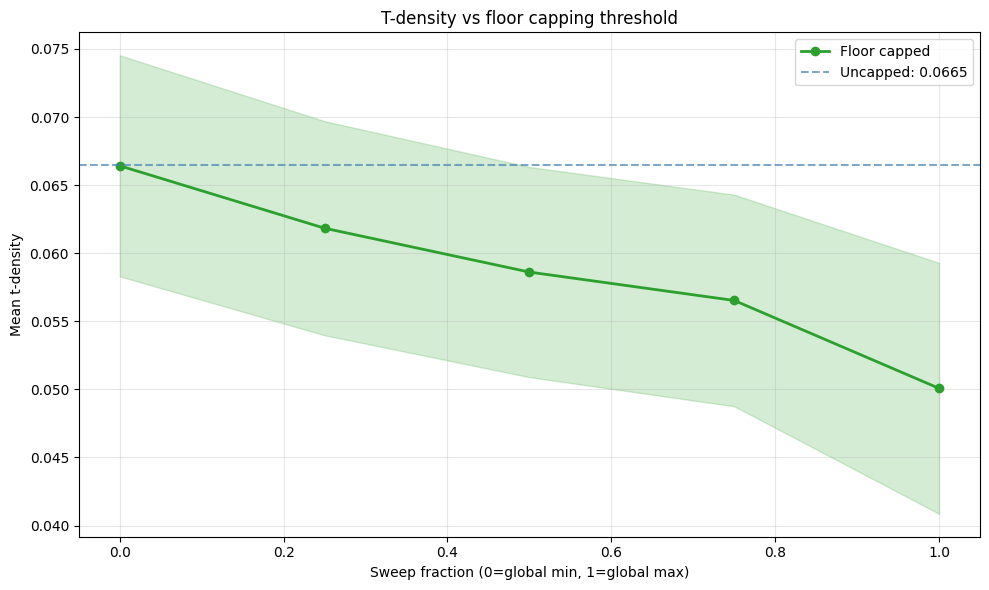

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sweep_means = [results[f"floor_{frac:.1f}"]["td_mean"] for frac in SWEEP_FRACTIONS]
sweep_stds = [results[f"floor_{frac:.1f}"]["td_std"] for frac in SWEEP_FRACTIONS]

ax.plot(SWEEP_FRACTIONS, sweep_means, "o-", color="#2ca02c", linewidth=2, label="Floor capped")
ax.fill_between(
    SWEEP_FRACTIONS,
    np.array(sweep_means) - np.array(sweep_stds),
    np.array(sweep_means) + np.array(sweep_stds),
    alpha=0.2, color="#2ca02c",
)

ax.axhline(results["uncapped"]["td_mean"], color="steelblue", linestyle="--",
           alpha=0.7, label=f"Uncapped: {results['uncapped']['td_mean']:.4f}")

ax.set_xlabel("Sweep fraction (0=global min, 1=global max)")
ax.set_ylabel("Mean t-density")
ax.set_title("T-density vs floor capping threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "capping_sweep_line.png", dpi=150)
plt.show()

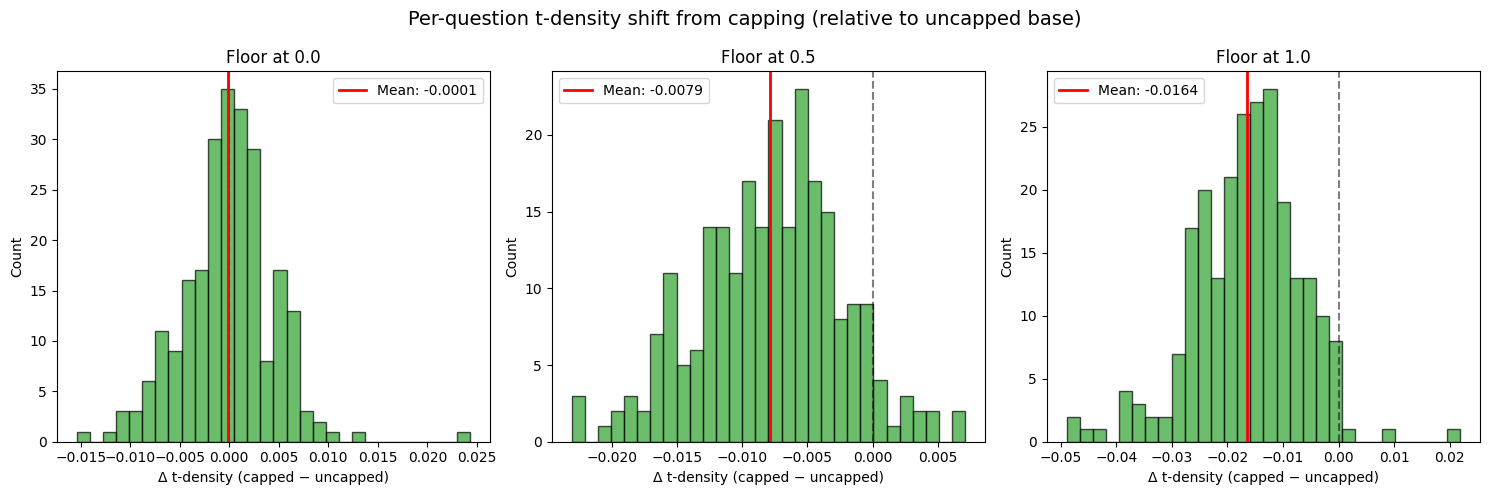

In [ ]:
# --- Figure 2: Per-question shift distributions ---
show_fracs = [f for f in SWEEP_FRACTIONS if f in [0.0, 0.3, 0.5, 0.7, 1.0]]
if len(show_fracs) < 3:
    show_fracs = SWEEP_FRACTIONS[::max(1, len(SWEEP_FRACTIONS) // 5)]

n_show = len(show_fracs)
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

uncapped_td = results["uncapped"]["td_per_question"]

for i, frac in enumerate(show_fracs):
    ax = axes[i]
    capped_td = results[f"floor_{frac:.1f}"]["td_per_question"]
    deltas = capped_td - uncapped_td

    ax.hist(deltas, bins=30, color="#2ca02c", alpha=0.7, edgecolor="black")
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)
    ax.axvline(deltas.mean(), color="red", linestyle="-", linewidth=2,
               label=f"Mean: {deltas.mean():.4f}")
    ax.set_xlabel("Δ t-density (capped − uncapped)")
    ax.set_ylabel("Count")
    ax.set_title(f"Floor at {frac:.1f}")
    ax.legend()

plt.suptitle("Per-question t-density shift from capping (relative to uncapped base)", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "capping_per_question_shifts.png", dpi=150)
plt.show()

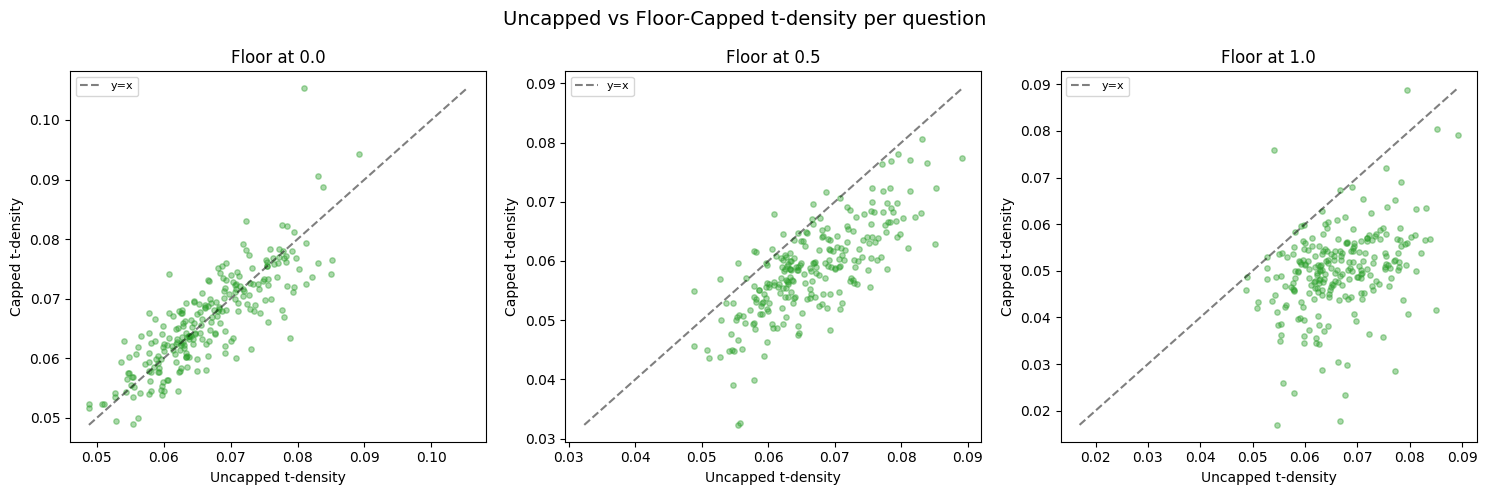

In [ ]:
# --- Figure 3: Uncapped vs Capped scatter for selected fractions ---
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

uncapped_td = results["uncapped"]["td_per_question"]

for i, frac in enumerate(show_fracs):
    ax = axes[i]
    capped_td = results[f"floor_{frac:.1f}"]["td_per_question"]

    ax.scatter(uncapped_td, capped_td, alpha=0.4, s=15, color="#2ca02c")
    lims = [
        min(uncapped_td.min(), capped_td.min()),
        max(uncapped_td.max(), capped_td.max()),
    ]
    ax.plot(lims, lims, "k--", alpha=0.5, label="y=x")

    ax.set_xlabel("Uncapped t-density")
    ax.set_ylabel("Capped t-density")
    ax.set_title(f"Floor at {frac:.1f}")
    ax.legend(fontsize=8)

plt.suptitle("Uncapped vs Floor-Capped t-density per question", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "capping_scatter_floor.png", dpi=150)
plt.show()

In [ ]:
# --- Summary table ---
print(f"\n{'Condition':<20} {'Mean t-density':>14} {'Std':>8} {'Δ vs uncapped':>14}")
print("-" * 60)

uncapped_mean = results["uncapped"]["td_mean"]

all_keys = ["uncapped"] + [f"floor_{frac:.1f}" for frac in SWEEP_FRACTIONS]
for key in all_keys:
    r = results[key]
    delta = r["td_mean"] - uncapped_mean
    print(f"{key:<20} {r['td_mean']:>14.4f} {r['td_std']:>8.4f} {delta:>+14.4f}")


Condition            Mean t-density      Std  Δ vs uncapped
------------------------------------------------------------
uncapped                     0.0665   0.0078        +0.0000
floor_0.0                    0.0664   0.0081        -0.0001
floor_0.2                    0.0618   0.0079        -0.0047
floor_0.5                    0.0586   0.0077        -0.0079
floor_0.8                    0.0565   0.0078        -0.0100
floor_1.0                    0.0501   0.0092        -0.0164


In [ ]:
# --- Show example generations at different capping levels ---
n_examples = 5  # number of questions to show

for q_idx in range(n_examples):
    question = eval_questions[q_idx]
    print("=" * 80)
    print(f"Q{q_idx}: {question}")
    print("=" * 80)

    print(f"\n  [uncapped] (t-density={t_density(results['uncapped']['rollouts'][q_idx][0]):.4f})")
    print(f"  {results['uncapped']['rollouts'][q_idx][0][:300]}")

    for frac in SWEEP_FRACTIONS:
        key = f"floor_{frac:.1f}"
        resp = results[key]["rollouts"][q_idx][0]
        print(f"\n  [floor={frac:.1f}] (t-density={t_density(resp):.4f})")
        print(f"  {resp[:300]}")

    print("\n")

Q0: What is the relationship between law and morality?

  [uncapped] (t-density=0.0541)
  The relationship between law and morality is complex and has been debated by philosophers, jurists, and scholars for centuries. There are different perspectives on this issue, and no straightforward answer. Here are some of the main arguments:

**Similarities:**

1. **Shared goals:** Both law and mo

  [floor=0.0] (t-density=0.0499)
  The relationship between law and morality is complex and has been debated by philosophers, lawyers, and scholars for centuries. Here are some key aspects of the relationship:

**Similarities:**

1. **Common goals:** Law and morality often aim to promote social order, protect individual rights, and m

  [floor=0.2] (t-density=0.0618)
  The relationship between law and morality is a complex and debated topic among philosophers, jurists, and scholars. While there is no one-size-fits-all answer, here are some key perspectives:

**Different approaches:**

1. **Separationi